## Objective

The objective of this project is to analyze an insurance dataset in order to understand the factors that affect insurance charges.

This project focuses on:
- Exploring the dataset to understand its structure and features
- Identifying and handling missing values
- Performing exploratory data analysis (EDA) to discover patterns and relationships
- Visualizing key variables such as age, BMI, smoking status, and charges
- Preparing the data for modeling through preprocessing
- Building a machine learning model to predict insurance charges

The main goal is to gain insights from the data and develop a model that can estimate insurance costs based on individual characteristics.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Load Dataset

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Understand Data

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


- The dataset contains 1338 rows and 7 columns.

## 4. Handle Missing Values

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

- There are no missing values in the dataset.

## 5. EDA

### Age vs Charges

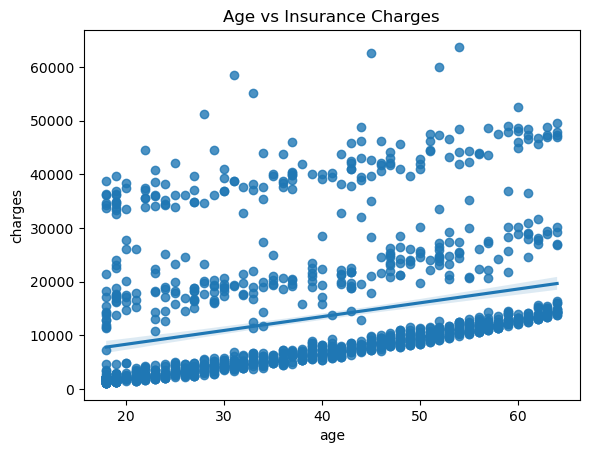

In [7]:
sns.regplot(x='age', y='charges', data=df)
plt.title("Age vs Insurance Charges")
plt.show()

**Insight:**
- Charges increase with age (moderate trend)

### BMI vs Charges

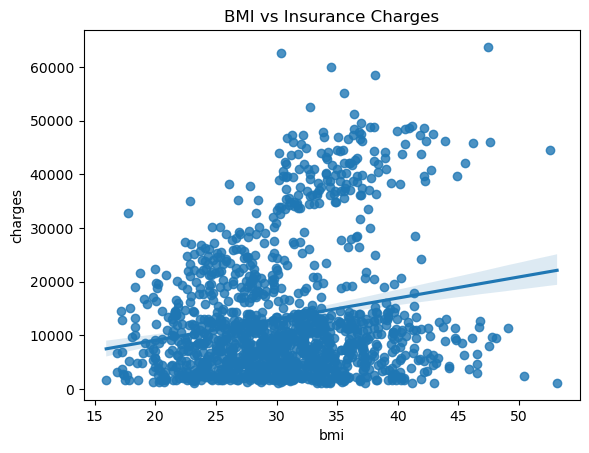

In [8]:
sns.regplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

**Insight:**

- Higher BMI → higher charges (but weaker than smoking)

### Smoker vs Charges

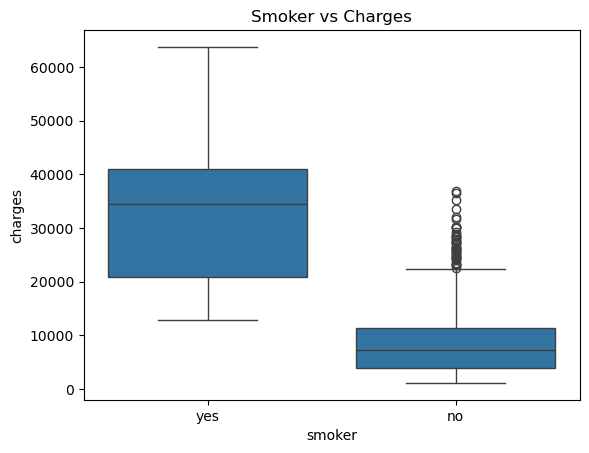

In [9]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()

**Insight:**

- Smokers have significantly higher charges

## 6. Correlation Heatmap

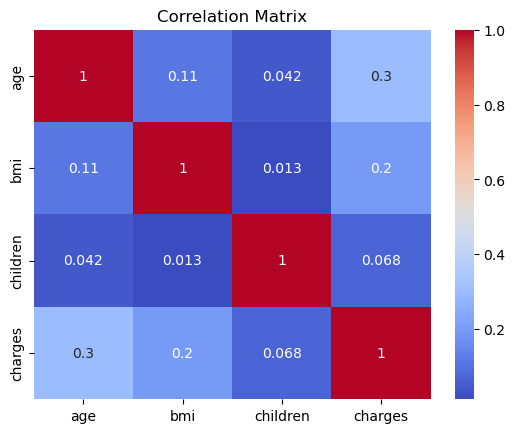

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Insight:**

- Smoking → strongest impact
- Age → moderate
- BMI → moderate

## 7. Encode Categorical Data

In [12]:
df = pd.get_dummies(df, drop_first=True)

## 8. Split Data

In [13]:
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 9. Train Linear Regression

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Linear Regression assumes a linear relationship between input features and the target variable. This assumption may not fully capture complex patterns in insurance cost prediction.

## 9. Evaluation

### MAE

In [15]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 4181.19447375365


### RMSE

In [16]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 5796.284659276272


## Model Evaluation

- MAE represents the average prediction error in insurance charges.
- RMSE is higher than MAE, indicating some larger prediction errors.
- The model performs reasonably well but can be improved with more advanced techniques.

## Key Insights

- Smoking is the most influential factor affecting insurance charges.
- Age has a positive relationship with charges.
- BMI also impacts charges but less strongly than smoking.

## Conclusion

- Smoking is the most significant factor affecting insurance charges, with smokers incurring substantially higher costs.
- Age shows a positive relationship with insurance charges, indicating that older individuals tend to have higher medical expenses.
- BMI also influences charges, but its impact is less significant compared to smoking.
- The Linear Regression model provides a reasonable estimate of insurance costs, although some prediction errors exist.

This project demonstrates how regression models can be used to estimate real-world financial outcomes and support decision-making in the insurance industry.